In [63]:
#import libraries
import yfinance as yf
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [64]:
#Portfolio construction

TICKERS = [
    # --- 1. US EQUITIES (Sector Diversification) ---
    "MSFT",   # Technology (Software & Cloud)
    "NVDA",   # Technology (Semiconductors)
    "LLY",    # Healthcare / Pharmaceuticals
    "JPM",    # Financials / Investment Banking
    "AMZN",   # Consumer Cyclical / E-Commerce
    "PG",     # Consumer Defensive / Consumer Goods
    "XOM",    # Energy / Oil & Gas
    "CAT",    # Industrials / Heavy Machinery
    "NEE",    # Utilities / Renewable Energy
    "AMT",    # Real Estate (REIT / Telecom Towers)

    # --- 2. INTERNATIONAL EQUITIES (Geographic Diversification) ---
    "ASML",   # Europe (Netherlands) - Semi-cap Equipment
    "NSRGY",  # Europe (Switzerland) - Consumer Goods (Nestlé)
    "SAP",    # Europe (Germany) - Enterprise Software
    "TM",     # Asia (Japan) - Automotive (Toyota)
    "SONY",   # Asia (Japan) - Electronics & Entertainment
    "TSM",    # Asia (Taiwan) - Semiconductor Foundry
    "BABA",   # Emerging Markets (China) - Tech & Retail
    "HDB",    # Emerging Markets (India) - Banking & Finance
    "VALE",   # Emerging Markets (Brazil) - Materials & Mining
    "RY",     # North America (Canada) - Banking (Royal Bank)

    # --- 3. FIXED INCOME (Bonds for De-correlation) ---
    "TLT",    # US Long-Term Treasury Bonds (20+ Years)
    "IEF",    # US Intermediate-Term Treasury Bonds (7-10 Years)
    "TIP",    # US Inflation-Protected Treasury Bonds (TIPS)
    "BNDX",   # Total International Bond ETF (Non-US Hedged)
    "EMB",    # Emerging Markets Sovereign Bond ETF

    # --- 4. ALTERNATIVE ASSETS & COMMODITIES (Alternative Allocation) ---
    "GLD",    # Gold Shares (Traditional Safe Haven)
    "SLV",    # Silver Shares (Precious & Industrial Metal)
    "USO",    # United States Oil Fund (WTI Crude Oil)
    "DBA",    # Invesco Agricultural Fund (Corn, Wheat, Soy, Coffee)
    "IBIT"    # iShares Bitcoin Trust (Spot Bitcoin ETF)
]



START = "2015-01-01"
END = "2025-01-01"
RF = 0.045  # Risk-free rate
PORTFOLIO_VALUE = 1000000  # Portfolio value
n = len(TICKERS)  # Number of tickers

#Data collection

df = yf.download(TICKERS, start=START, end=END, auto_adjust = True)['Close']
df.dropna(how='all', inplace=True)
df.ffill()  # forward-fill sporadic NaNs
df.dropna(inplace=True)

returns = df.pct_change().dropna()
print(f"{len(returns)} trading days of returns data collected for {n} assets from {START} to {END}.")

df.head()

[*********************100%***********************]  30 of 30 completed

244 trading days of returns data collected for 30 assets from 2015-01-01 to 2025-01-01.


Ticker,AMT,AMZN,ASML,BABA,BNDX,CAT,DBA,EMB,GLD,HDB,...,SAP,SLV,SONY,TIP,TLT,TM,TSM,USO,VALE,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2024-01-11,190.302521,155.179993,703.594055,69.028999,44.498440,281.975616,19.213295,77.450386,187.869995,31.917757,...,150.567841,20.820000,19.276686,98.495590,86.964180,186.341217,97.973999,67.650002,12.025746,90.811577
2024-01-12,191.933807,154.619995,698.394409,68.514000,44.498440,280.382599,19.111296,77.590652,189.710007,32.015396,...,152.520767,21.190001,19.760040,98.917740,86.793297,187.039001,97.993347,68.019997,11.936846,91.989632
2024-01-16,190.669113,153.160004,691.814270,66.244186,44.280930,277.312408,19.250389,76.871826,187.910004,29.867367,...,150.866074,20.959999,19.445066,98.413017,85.264656,186.962524,98.409569,67.250000,11.565082,89.909637
2024-01-17,187.828064,151.710007,697.464233,65.738724,44.154041,269.009369,19.111296,76.582527,185.839996,27.138391,...,151.789627,20.650000,19.296497,98.110176,85.129738,185.566986,99.648514,67.940002,11.363036,89.256180
2024-01-18,186.874969,153.500000,729.053650,64.899467,44.135918,272.166412,19.333843,76.661407,187.369995,27.592407,...,154.339005,20.809999,19.383657,98.137695,84.338425,191.244690,109.405266,69.059998,11.346872,89.090515


In [65]:
#Performance metrics
mean_returns = returns.mean()*252  # Annualized mean returns
volatility = returns.std()*np.sqrt(252)  # Annualized volatility
cov_matrix = returns.cov()*252  # Annualized covariance matrix

risk_df = pd.DataFrame({
    'Ann. Return' : mean_returns,
    'Ann. Volatility' : volatility,
    'Sharpe Ratio' : (mean_returns - RF) / volatility 
}).round(4)

print("Individual stock performance metrics:\n")
print(risk_df.to_string())

Individual stock performance metrics:

        Ann. Return  Ann. Volatility  Sharpe Ratio
Ticker                                            
AMT         -0.0627           0.2489       -0.4330
AMZN         0.3973           0.2815        1.2518
ASML         0.0753           0.4528        0.0669
BABA         0.2559           0.3773        0.5591
BNDX         0.0425           0.0376       -0.0668
CAT          0.2746           0.2621        0.8759
DBA          0.3144           0.1744        1.5444
EMB          0.0665           0.0713        0.3011
GLD          0.2737           0.1519        1.5053
HDB          0.0282           0.2834       -0.0591
IBIT         0.8750           0.5726        1.4495
IEF          0.0002           0.0674       -0.6648
JPM          0.3993           0.2381        1.4881
LLY          0.2531           0.3038        0.6851
MSFT         0.1224           0.2004        0.3862
NEE          0.2338           0.2549        0.7407
NSRGY       -0.2895           0.1966       

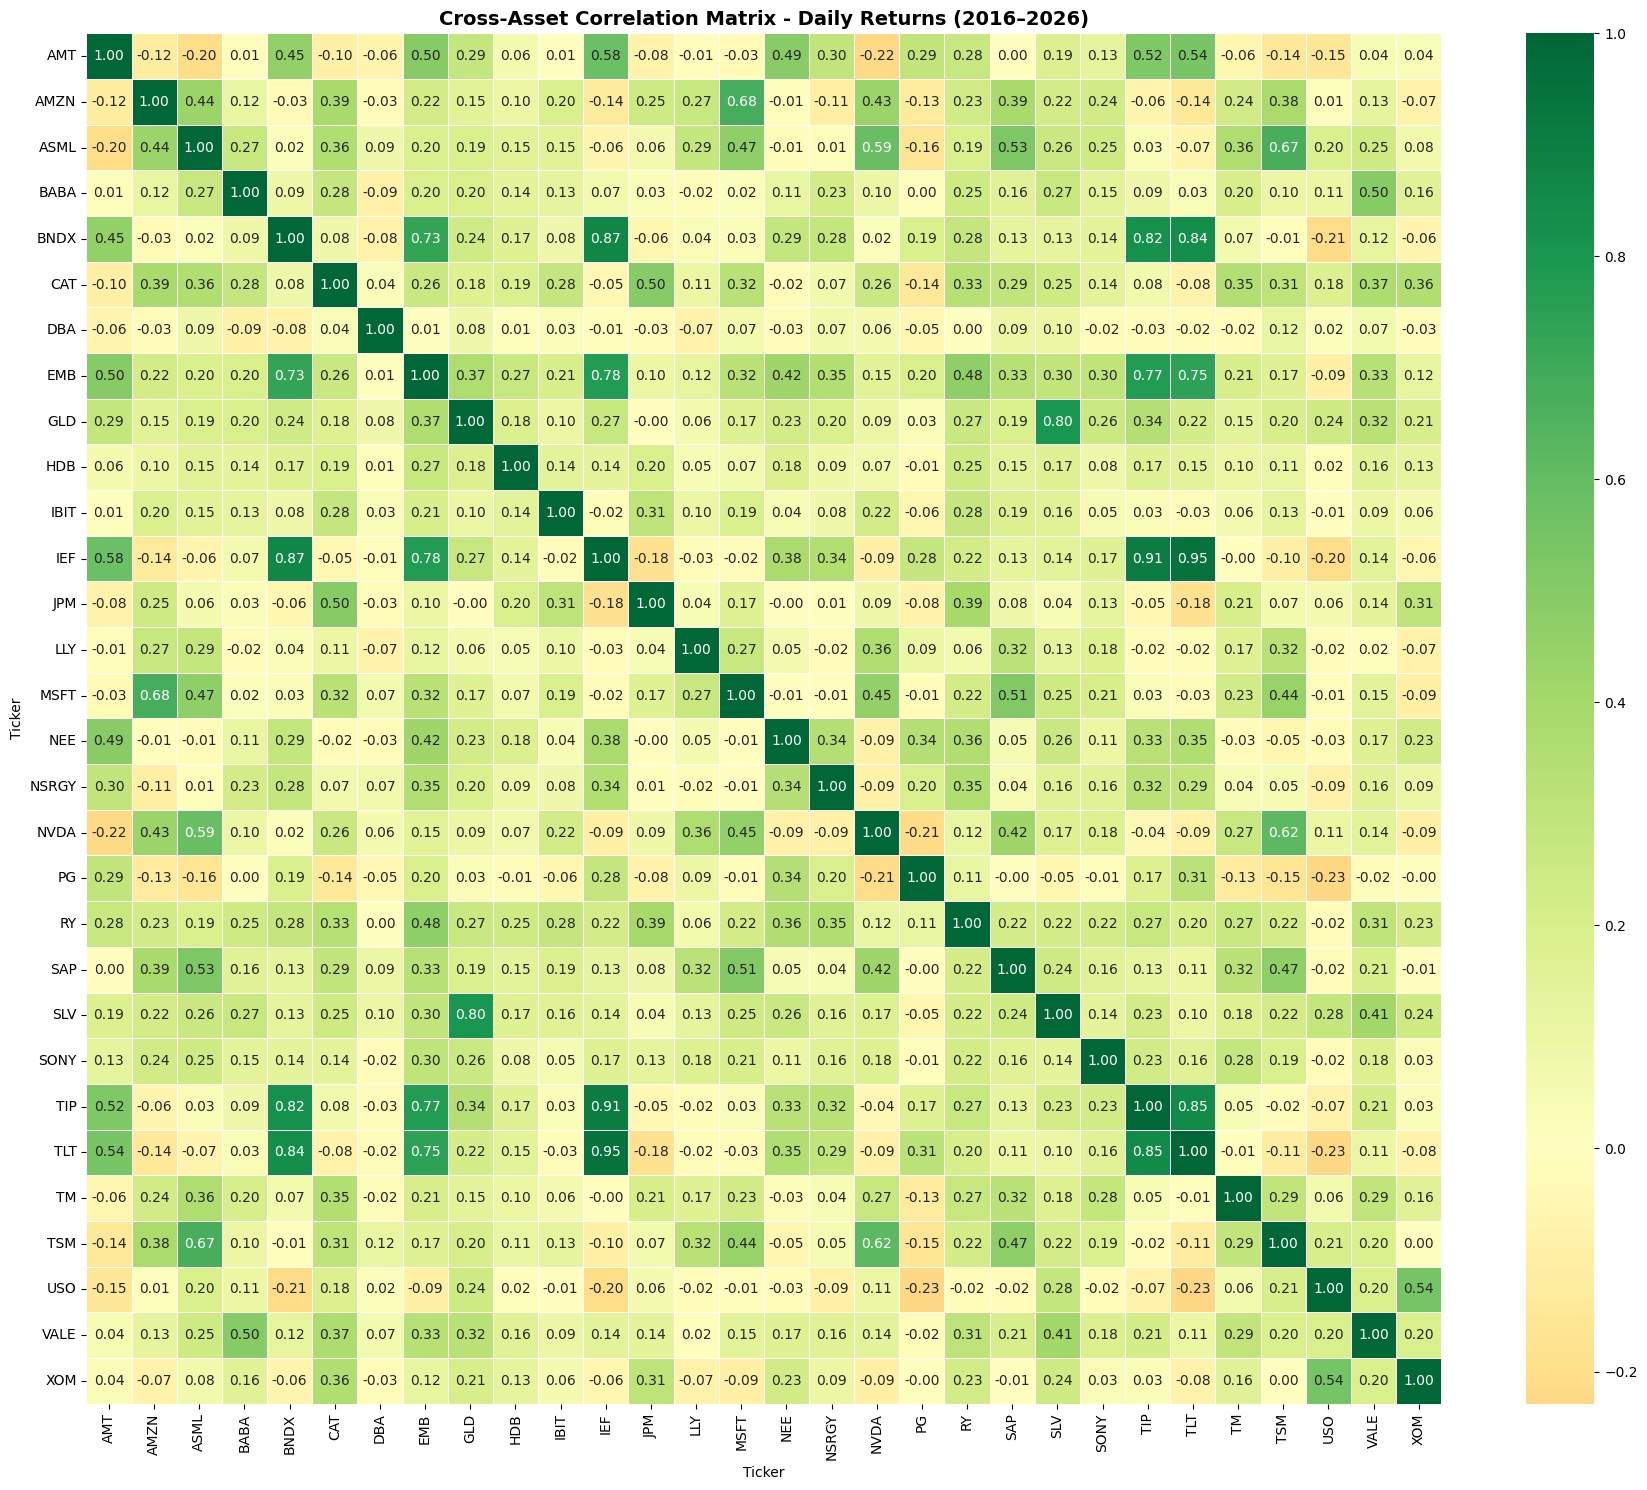

In [66]:
#Correlation heatmap
fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(returns.corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax, linewidths=0.5)

ax.set_title('Cross-Asset Correlation Matrix - Daily Returns (2016–2026)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [73]:
#We create an equal weight portfolio

weights_eq = np.array([1/n]*n)  # Equal weights for each asset
port_ret_eq = np.sum(returns.mean() * 252 * weights_eq)
port_vol_eq = np.sqrt(np.dot(weights_eq.T, np.dot(cov_matrix, weights_eq)))
sharpe_eq = (port_ret_eq - RF) / port_vol_eq

print(f"Portfolio Performance Metrics:\n")

print("="*45)
print(f" {'':20}{'Equal Weight Portfolio':>20}")
print(f"{'Expected Return': <20} {port_ret_eq:.4f}")   
print(f"{'Volatility': <20} {port_vol_eq:.4f}")
print(f"{'Sharpe Ratio': <20} {sharpe_eq:.4f}")
print("="*45)

Portfolio Performance Metrics:

                     Equal Weight Portfolio
Expected Return      0.2119
Volatility           0.1084
Sharpe Ratio         1.5399


In [ ]:
#Portfolio Optimization using Monte Carlo Simulation

